In [6]:
import pandas as pd

In [8]:
import rasterio
import numpy as np

def extract_features_tif(path):
    with rasterio.open(path) as src:
        img = src.read()  # shape: (bands, height, width)

    img = img.astype(np.float32)

    features = []
    features.extend(np.mean(img, axis=(1,2)))  # mean per band
    features.extend(np.std(img, axis=(1,2)))   # std per band

    features.append(np.mean(img))  # overall mean
    features.append(np.std(img))   # overall std

    return np.array(features)

In [ ]:
from pathlib import Path

ROOT = Path("..")

formal_dir = ROOT / "data" / "Formal_Settlement_Images"
slum_dir = ROOT / "data" / "Informal_Settlement_Images"

formal_files = sorted(formal_dir.glob("*.tif"))
slum_files = sorted(slum_dir.glob("*.tif"))

print("formal:", len(formal_files))
print("slum:", len(slum_files))

X_list = []
y_list = []
paths = []

# formal = 0
for p in formal_files:
    X_list.append(extract_features_tif(p))
    y_list.append(0)
    paths.append(p)

# slum = 1
for p in slum_files:
    X_list.append(extract_features_tif(p))
    y_list.append(1)
    paths.append(p)

X = np.vstack(X_list)
y = np.array(y_list)
paths = np.array(paths)

print("X shape:", X.shape)

formal: 599
slum: 593
X shape: (1192, 10)


In [12]:
from sklearn.model_selection import train_test_split
import numpy as np

idx = np.arange(len(y))

idx_train, idx_test, y_train, y_test = train_test_split(
    idx,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train = X[idx_train]
X_test = X[idx_test]

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)
proba = rf.predict_proba(X_test)[:, 1]

print("Confusion matrix:\n", confusion_matrix(y_test, pred))
print("\nReport:\n", classification_report(y_test, pred, digits=3))
print(f"ROC-AUC: {roc_auc_score(y_test, proba):.3f}")
print(f"PR-AUC:  {average_precision_score(y_test, proba):.3f}")

Confusion matrix:
 [[104  16]
 [  4 115]]

Report:
               precision    recall  f1-score   support

           0      0.963     0.867     0.912       120
           1      0.878     0.966     0.920       119

    accuracy                          0.916       239
   macro avg      0.920     0.917     0.916       239
weighted avg      0.921     0.916     0.916       239

ROC-AUC: 0.982
PR-AUC:  0.983


In [ ]:
fp = np.where((pred == 1) & (y_test == 0))[0]
fn = np.where((pred == 0) & (y_test == 1))[0]

print("False positives:", len(fp))
print("False negatives:", len(fn))

In [15]:
import matplotlib.pyplot as plt
import rasterio

def show_examples(indices, n=6):
    
    n = min(n, len(indices))
    
    plt.figure(figsize=(12,8))
    
    for i in range(n):
        test_i = indices[i]
        global_i = idx_test[test_i]
        path = paths[global_i]

        with rasterio.open(path) as src:
            img = src.read([1,2,3])
        
        img = np.transpose(img,(1,2,0))
        img = (img - img.min())/(img.max()-img.min())

        plt.subplot(2,3,i+1)
        plt.imshow(img)
        plt.title(path.name)
        plt.axis("off")

    plt.show()

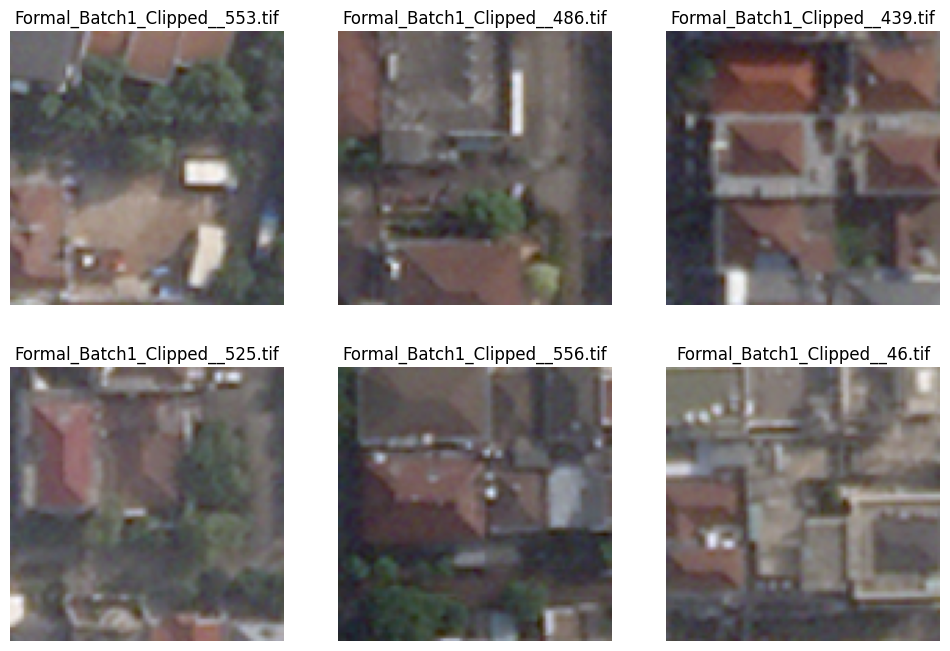

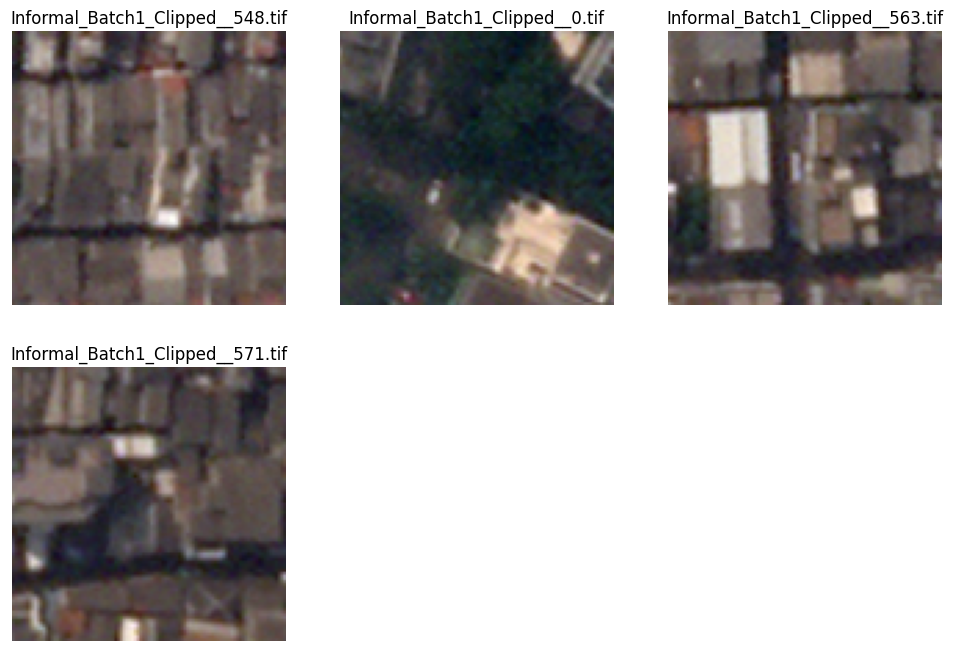

In [16]:
show_examples(fp)
show_examples(fn)